# Model 3 Grass Segmentation: ResNet50 + U-Net




In [1]:
# OPTIONAL COLAB SETUP
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile

In [3]:
img_zip_path = "/content/drive/MyDrive/split_3.zip"

with zipfile.ZipFile(img_zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [4]:
# ResNet50 + U-Net (Model 3)
# import library
import os
import json
import math
import random
from types import SimpleNamespace

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow import data as tf_data
from tensorflow import io as tf_io
from tensorflow import image as tf_image
from tensorflow import keras
from tensorflow.keras.applications import resnet50

preprocess_input = resnet50.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

In [5]:
# REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# CONFIGURATION
DATA_ROOT = "/content/dataset/split_3"
TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train", "images")
TRAIN_MSK_DIR = os.path.join(DATA_ROOT, "train", "masks")
VAL_IMG_DIR   = os.path.join(DATA_ROOT, "val", "images")
VAL_MSK_DIR   = os.path.join(DATA_ROOT, "val", "masks")
TEST_IMG_DIR  = os.path.join(DATA_ROOT, "test", "images")
TEST_MSK_DIR  = os.path.join(DATA_ROOT, "test", "masks")

OUTPUT_ROOT  = "/content/model3_resnet50_u_net_v1_7"
MODEL_DIR    = os.path.join(OUTPUT_ROOT, "models")
RESULT_DIR   = os.path.join(OUTPUT_ROOT, "results")
HISTORY_DIR  = os.path.join(OUTPUT_ROOT, "history")
LOG_DIR      = os.path.join(OUTPUT_ROOT, "logs")

# Define path for model & history
HEAD_CKPT_PATH    = os.path.join(MODEL_DIR, "resnet50_unet_phase1.keras")
FINE_CKPT_PATH    = os.path.join(MODEL_DIR, "resnet50_unet_phase2.keras")
HEAD_HISTORY_PATH = os.path.join(HISTORY_DIR, "history_phase1.json")
FINE_HISTORY_PATH = os.path.join(HISTORY_DIR, "history_phase2.json")
REPORT_PATH       = os.path.join(RESULT_DIR, "evaluation_report.json")

for folder in [OUTPUT_ROOT, MODEL_DIR, RESULT_DIR,
               HISTORY_DIR, LOG_DIR]:
    os.makedirs(folder, exist_ok=True)

IMG_SIZE   = 256
IMG_SHAPE  = (IMG_SIZE, IMG_SIZE)
BATCH_SIZE = 32

NUM_CLASSES = 4
CLASS_NAMES = {
    0: "background",
    1: "grass_short",
    2: "grass_medium",
    3: "grass_long",
}

PHASE1_EPOCHS = 20
PHASE2_EPOCHS = 10

PHASE1_LR = 3e-4
PHASE2_LR = 3e-5

freqs   = np.array([0.931, 0.038, 0.018, 0.013])
weights = 1.0 / np.sqrt(freqs)
weights = weights / weights.mean()
CLASS_WEIGHTS = {i: float(weights[i]) for i in range(4)}

DECODER_FILTERS = [512, 256, 128, 64, 32]

DROPOUT_RATE = 0.1

print("Hyperparameters used")
print(f"  Image size      : {IMG_SHAPE}")
print(f"  Num classes     : {NUM_CLASSES}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Epochs          : Phase 1 = {PHASE1_EPOCHS}, Phase 2 = {PHASE2_EPOCHS}")
print(f"  Class weights   : {CLASS_WEIGHTS}")
print(f"  Decoder filters : {DECODER_FILTERS}")
print(f"  Dropout         : {DROPOUT_RATE}")
print(f"  Learning rate   : Phase 1 = {PHASE1_LR}, Phase 2 = {PHASE2_LR}")


Hyperparameters used
  Image size      : (256, 256)
  Num classes     : 4
  Batch size      : 32
  Epochs          : Phase 1 = 20, Phase 2 = 10
  Class weights   : {0: 0.18514960258013413, 1: 0.91644377662885, 2: 1.3315619365873061, 3: 1.5668446842037094}
  Decoder filters : [512, 256, 128, 64, 32]
  Dropout         : 0.1
  Learning rate   : Phase 1 = 0.0003, Phase 2 = 3e-05


# Processing dataset

In [6]:
# Verify and match data
print("Verifying data...")
for name, img_dir, mask_dir in [
    ("Train", TRAIN_IMG_DIR, TRAIN_MSK_DIR),
    ("Val",   VAL_IMG_DIR,   VAL_MSK_DIR),
    ("Test",  TEST_IMG_DIR,  TEST_MSK_DIR),
]:
    n_img  = len(os.listdir(img_dir))
    n_mask = len(os.listdir(mask_dir))
    match  = "OK" if n_img == n_mask else "MISMATCH"
    print(f"  {name:<6} images: {n_img:>5}  masks: {n_mask:>5}  [{match}]")

Verifying data...
  Train  images:  4796  masks:  4796  [OK]
  Val    images:   600  masks:   600  [OK]
  Test   images:   600  masks:   600  [OK]


In [7]:
# Pair the original image and its mask
def get_path_pairs(image_dir, mask_dir):
    image_files = sorted(os.listdir(image_dir))
    img_paths   = []
    mask_paths  = []
    missing     = []

    for img_file in image_files:
        stem      = os.path.splitext(img_file)[0]
        mask_file = stem + ".png"
        img_path  = os.path.join(image_dir, img_file)
        mask_path = os.path.join(mask_dir,  mask_file)

        if os.path.exists(mask_path):
            img_paths.append(img_path)
            mask_paths.append(mask_path)
        else:
            missing.append(img_file)

    print(f"  Pairs: {len(img_paths)}  Missing: {len(missing)}")
    return img_paths, mask_paths

print("Building path pairs...")
train_img_paths,  train_mask_paths  = get_path_pairs(TRAIN_IMG_DIR, TRAIN_MSK_DIR)
val_img_paths,    val_mask_paths    = get_path_pairs(VAL_IMG_DIR,   VAL_MSK_DIR)
test_img_paths,   test_mask_paths   = get_path_pairs(TEST_IMG_DIR,  TEST_MSK_DIR)

print(f"\nTrain : {len(train_img_paths)}")
print(f"Val   : {len(val_img_paths)}")
print(f"Test  : {len(test_img_paths)}")

Building path pairs...
  Pairs: 4796  Missing: 0
  Pairs: 600  Missing: 0
  Pairs: 600  Missing: 0

Train : 4796
Val   : 600
Test  : 600


In [8]:
# DATA PIPELINE
def load_img_mask(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SHAPE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SHAPE, method="nearest")
    mask = tf.cast(mask, tf.uint8)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES, dtype=tf.float32)

    return img, mask


def preprocess_resnet(img, mask):
    img = preprocess_input(img * 255.0)
    return img, mask

In [9]:
def augment_fn(img, mask):
    # Random horizontal flip
    if tf.random.uniform(()) > 0.5:
        img = tf_image.flip_left_right(img)
        mask = tf_image.flip_left_right(mask)

    # Random vertical flip
    if tf.random.uniform(()) > 0.5:
        img = tf_image.flip_up_down(img)
        mask = tf_image.flip_up_down(mask)

    # Random contrast
    img = tf_image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)

    # Random saturation
    img = tf_image.random_saturation(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 1.0)

    # Random hue
    img = tf_image.random_hue(img, max_delta=0.05)
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img, mask

In [10]:
def get_dataset(img_paths, mask_paths, batch_size, augment=False, shuffle=False, repeat=False):
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    ds = ds.map(load_img_mask, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED, reshuffle_each_iteration=True)

    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)

    ds = ds.map(preprocess_resnet, num_parallel_calls=AUTOTUNE)

    if repeat:
        ds = ds.repeat()

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_dataset = get_dataset(train_img_paths, train_mask_paths, BATCH_SIZE, augment=True,  shuffle=True,  repeat=True)
val_dataset   = get_dataset(val_img_paths,   val_mask_paths,   BATCH_SIZE, augment=False, shuffle=False, repeat=False)
test_dataset  = get_dataset(test_img_paths,  test_mask_paths,  BATCH_SIZE, augment=False, shuffle=False, repeat=False)

print(f"Val batches   : {len(val_dataset)}")
print(f"Test batches  : {len(test_dataset)}")


Val batches   : 19
Test batches  : 19


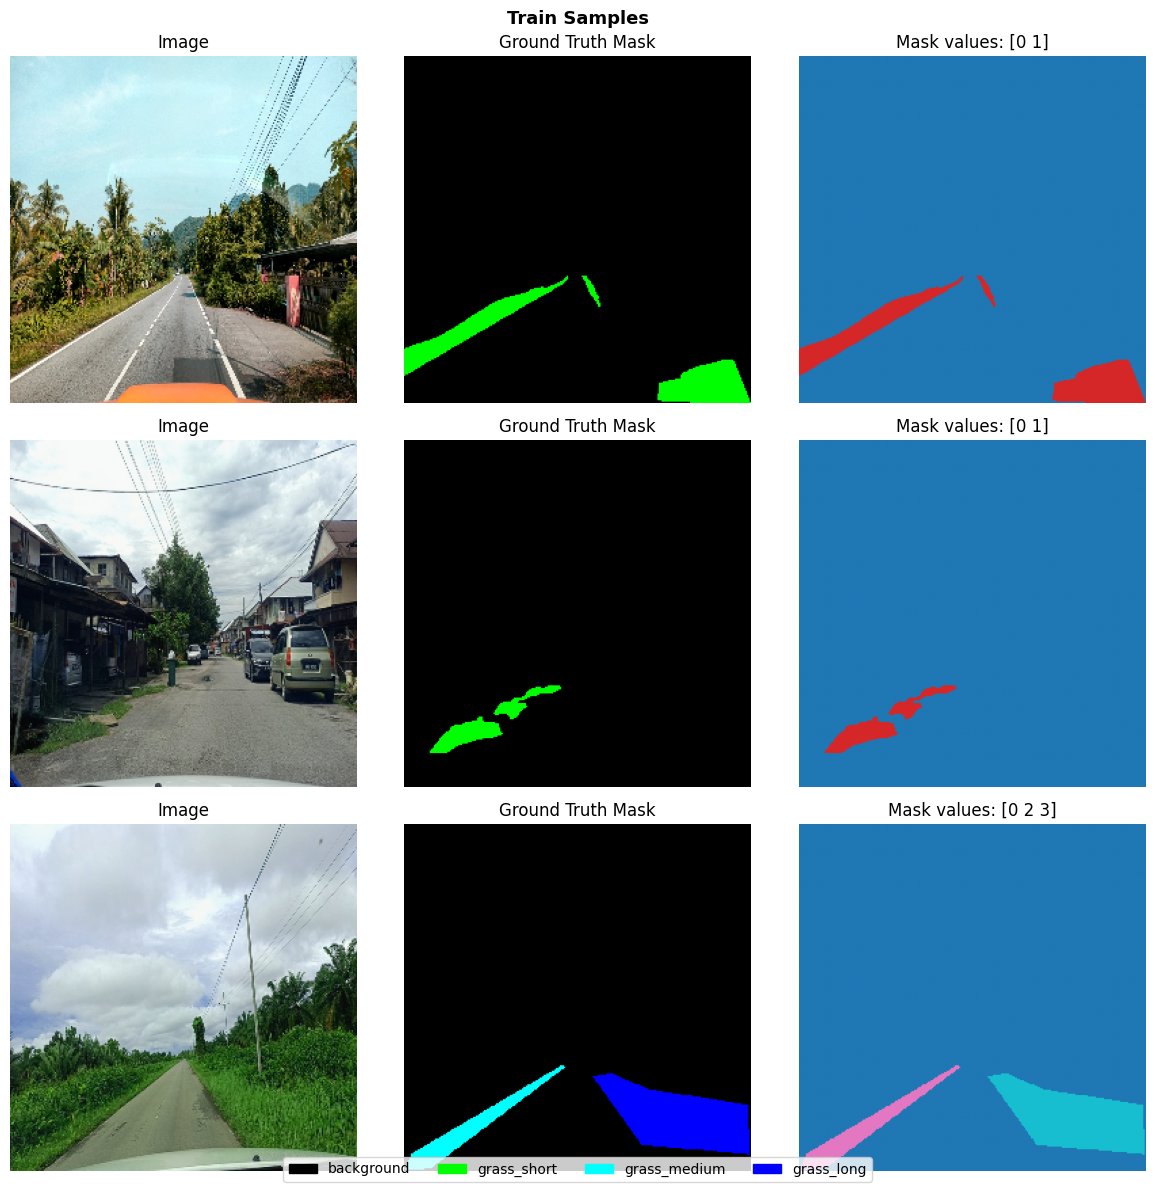

In [11]:
# Visualize samples
CLASS_COLORS = {
    0: [0,   0,   0],    # background  black
    1: [0,   255, 0],    # grass_short green
    2: [0,   255, 255],  # grass_medium yellow
    3: [0,   0,   255],  # grass_long  red
}

def mask_to_rgb(mask):
    if hasattr(mask, 'numpy'):
        mask = mask.numpy()
    if mask.ndim == 3 and mask.shape[-1] == NUM_CLASSES:
        mask = np.argmax(mask, axis=-1)
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in CLASS_COLORS.items():
        rgb[mask == class_id] = color
    return rgb

def deprocess_resnet_image(img):
    img = img.copy()

    # Undo ResNet50 preprocess_input
    img[..., 0] += 103.939
    img[..., 1] += 116.779
    img[..., 2] += 123.68

    # BGR back to RGB
    img = img[..., ::-1]

    # Clip for display
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def show_samples(dataset, n=3, title="Samples"):
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for images, masks in dataset.take(1):
        for i in range(min(n, len(images))):
            display_img = deprocess_resnet_image(images[i].numpy())
            axes[i][0].imshow(display_img)
            axes[i][0].set_title("Image")
            axes[i][0].axis("off")

            axes[i][1].imshow(mask_to_rgb(masks[i]))
            axes[i][1].set_title("Ground Truth Mask")
            axes[i][1].axis("off")

            # Show mask raw values
            mask_raw = np.argmax(masks[i].numpy(), axis=-1)
            unique = np.unique(mask_raw)
            axes[i][2].imshow(mask_raw, cmap="tab10", vmin=0, vmax=3)
            axes[i][2].set_title(f"Mask values: {unique}")
            axes[i][2].axis("off")

    # Legend
    patches = [mpatches.Patch(color=np.array(c)/255, label=CLASS_NAMES[k])
               for k, c in CLASS_COLORS.items()]
    fig.legend(handles=patches, loc="lower center", ncol=4)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "sample_images.png"), dpi=150)
    plt.show()

show_samples(train_dataset, n=3, title="Train Samples")

In [12]:
# History helper

def history_to_dict(history_obj):
    hist = history_obj.history if hasattr(history_obj, "history") else history_obj
    return {k: [float(vv) for vv in v] for k, v in hist.items()}

def save_history_json(history_obj, path):
    with open(path, "w") as f:
        json.dump(history_to_dict(history_obj), f, indent=2)

def load_history_json(path):
    with open(path, "r") as f:
        hist = json.load(f)
    return SimpleNamespace(history=hist)

# Build Model

In [13]:
# MODEL
def conv_bn_relu(x, filters, dropout_rate=0.1, name_prefix="block"):
    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name_prefix}_conv1",
    )(x)
    x = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn1")(x)
    x = tf.keras.layers.Activation("relu", name=f"{name_prefix}_act1")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name=f"{name_prefix}_drop1")(x)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name_prefix}_conv2",
    )(x)
    x = tf.keras.layers.BatchNormalization(name=f"{name_prefix}_bn2")(x)
    x = tf.keras.layers.Activation("relu", name=f"{name_prefix}_act2")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name=f"{name_prefix}_drop2")(x)
    return x


def decoder_block(x, skip, filters, dropout_rate=0.1, block_name="decoder"):
    x = tf.keras.layers.UpSampling2D(size=(2, 2), interpolation="bilinear", name=f"{block_name}_up")(x)
    x = tf.keras.layers.Concatenate(name=f"{block_name}_concat")([x, skip])
    x = conv_bn_relu(x, filters, dropout_rate=dropout_rate, name_prefix=block_name)
    return x


def build_resnet50_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = tf.keras.Input(shape=input_shape, name="input_image")

    encoder = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
    )
    encoder._name = "resnet50_encoder"

    skip1 = encoder.get_layer("conv1_relu").output
    skip2 = encoder.get_layer("conv2_block3_out").output
    skip3 = encoder.get_layer("conv3_block4_out").output
    skip4 = encoder.get_layer("conv4_block6_out").output
    bridge = encoder.get_layer("conv5_block3_out").output

    x = decoder_block(bridge, skip4, DECODER_FILTERS[0], dropout_rate=DROPOUT_RATE, block_name="decoder1")
    x = decoder_block(x,      skip3, DECODER_FILTERS[1], dropout_rate=DROPOUT_RATE, block_name="decoder2")
    x = decoder_block(x,      skip2, DECODER_FILTERS[2], dropout_rate=DROPOUT_RATE, block_name="decoder3")
    x = decoder_block(x,      skip1, DECODER_FILTERS[3], dropout_rate=DROPOUT_RATE, block_name="decoder4")

    x = tf.keras.layers.UpSampling2D(size=(2, 2), interpolation="bilinear", name="final_up")(x)
    x = conv_bn_relu(x, DECODER_FILTERS[4], dropout_rate=DROPOUT_RATE, name_prefix="final_refine")

    outputs = tf.keras.layers.Conv2D(
        num_classes,
        1,
        padding="same",
        activation="softmax",
        dtype="float32",
        name="segmentation_head",
    )(x)

    model = tf.keras.Model(inputs, outputs, name="ResNet50_UNet")
    return model, encoder


model, encoder = build_resnet50_unet()
model.summary(line_length=120)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_UNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ input_image (InputLayer)          │ (None, 256, 256, 3)          │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_pad (ZeroPadding2D)         │ (None, 262, 262, 3)          │                 0 │ input_image[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_conv (Conv2D)               │ (None, 128, 128, 64)         │             9,472 │ conv1_pad[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_bn (BatchNormalization)     │ (None, 128, 128, 64)         │               256 │ conv1_conv[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_relu (Activation)           │ (None, 128, 128, 64)         │                 0 │ conv1_bn[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ pool1_pad (ZeroPadding2D)         │ (None, 130, 130, 64)         │                 0 │ conv1_relu[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ pool1_pool (MaxPooling2D)         │ (None, 64, 64, 64)           │                 0 │ pool1_pad[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_1_conv (Conv2D)      │ (None, 64, 64, 64)           │             4,160 │ pool1_pool[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_1_bn                 │ (None, 64, 64, 64)           │               256 │ conv2_block1_1_conv[0][0] 
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_1_relu (Activation)  │ (None, 64, 64, 64)           │                 0 │ conv2_block1_1_bn[0][0]   
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_2_conv (Conv2D)      │ (None, 64, 64, 64)           │            36,928 │ conv2_block1_1_relu[0][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_2_bn                 │ (None, 64, 64, 64)           │               256 │ conv2_block1_2_conv[0][0] 
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_2_relu (Activation)  │ (None, 64, 64, 64)           │                 0 │ conv2_block1_2_bn[0][0]   
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_0_conv (Conv2D)      │ (None, 64, 64, 256)          │            16,640 │ pool1_pool[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_3_conv (Conv2D)      │ (None, 64, 64, 256)          │            16,640 │ conv2_block1_2_relu[0][0] 
├───────────────────────────────────┼───────────────────

 Total params: 43,972,356 (167.74 MB)

 Trainable params: 43,915,268 (167.52 MB)

 Non-trainable params: 57,088 (223.00 KB)

# Metrics - IoU

In [14]:
# METRIC
class MeanIoUExcludeBackground(tf.keras.metrics.Metric):
    def __init__(self, num_classes=4, name="mean_iou_no_bg", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.iou = tf.keras.metrics.MeanIoU(num_classes=num_classes)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.argmax(y_true, axis=-1)
        y_pred = tf.argmax(y_pred, axis=-1)
        self.iou.update_state(y_true, y_pred, sample_weight=sample_weight)

    def result(self):
        cm = tf.cast(self.iou.total_cm, tf.float32)
        ious = []
        for c in range(1, self.num_classes):
            tp = cm[c, c]
            fp = tf.reduce_sum(cm[:, c]) - tp
            fn = tf.reduce_sum(cm[c, :]) - tp
            denom = tp + fp + fn
            iou_c = tf.where(denom > 0, tp / denom, 0.0)
            ious.append(iou_c)
        return tf.reduce_mean(tf.stack(ious))

    def reset_state(self):
        self.iou.reset_state()

    def reset_states(self):
        self.iou.reset_state()

    def get_config(self):
        config = super().get_config()
        config.update({"num_classes": self.num_classes})
        return config


In [15]:
# Compute mean IoU
class MeanIoUWrapper(tf.keras.metrics.MeanIoU):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.argmax(y_pred, axis=-1)
        return super().update_state(y_true, y_pred, sample_weight)

# Loss Function

In [16]:
# LOSSES
CW = tf.constant(list(CLASS_WEIGHTS.values()), dtype=tf.float32)

def weighted_cce(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
    cce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
    w = tf.reduce_sum(y_true * CW, axis=-1)
    return tf.reduce_mean(cce * w)


def focal_loss_foreground(y_true, y_pred, gamma=2.0):
    y_true_fg = y_true[..., 1:]   # exclude background
    y_pred_fg = tf.clip_by_value(y_pred[..., 1:], 1e-7, 1.0)

    fg_weights = tf.reshape(CW[1:], [1, 1, 1, -1])

    ce = -y_true_fg * tf.math.log(y_pred_fg)
    mod = tf.pow(1.0 - y_pred_fg, gamma)
    fl = fg_weights * ce * mod

    return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))


def tversky_loss_foreground(y_true, y_pred, alpha=0.3, beta=0.7, smooth=1e-6):
    y_true_fg = y_true[..., 1:]   # exclude background
    y_pred_fg = tf.clip_by_value(y_pred[..., 1:], 1e-7, 1.0)

    tp = tf.reduce_sum(y_true_fg * y_pred_fg, axis=[0, 1, 2])
    fp = tf.reduce_sum((1.0 - y_true_fg) * y_pred_fg, axis=[0, 1, 2])
    fn = tf.reduce_sum(y_true_fg * (1.0 - y_pred_fg), axis=[0, 1, 2])

    tversky = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)

    fg_weights = CW[1:] / tf.reduce_sum(CW[1:])
    return 1.0 - tf.reduce_sum(fg_weights * tversky)


def total_loss(y_true, y_pred):
    l1 = weighted_cce(y_true, y_pred)
    l2 = focal_loss_foreground(y_true, y_pred, gamma=2.0)
    l3 = tversky_loss_foreground(y_true, y_pred, alpha=0.3, beta=0.7)
    return 0.35 * l1 + 0.25 * l2 + 0.40 * l3

# Train model

In [17]:
# TRAINING HELPERS
def history_to_dict(history_obj):
    return {k: [float(v) for v in vals] for k, vals in history_obj.history.items()}


def save_history_json(history_obj, path):
    with open(path, "w") as f:
        json.dump(history_to_dict(history_obj), f, indent=2)


def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=total_loss,
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(name="categorical_accuracy"),
            MeanIoUExcludeBackground(num_classes=NUM_CLASSES, name="mean_iou_no_bg"),
        ],
    )

STEPS_PER_EPOCH = math.ceil(len(train_img_paths) / BATCH_SIZE)

def make_callbacks(checkpoint_path, log_subdir, phase):
    if phase == 1:
        reduce_patience = 5
        early_patience = 12
    else:
        reduce_patience = 2
        early_patience = 3

    return [
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_mean_iou_no_bg",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_mean_iou_no_bg",
            mode="max",
            factor=0.5,
            patience=reduce_patience,
            min_lr=1e-6,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_mean_iou_no_bg",
            mode="max",
            patience=early_patience,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.TensorBoard(
            log_dir=os.path.join(LOG_DIR, log_subdir)
        ),
    ]


def load_saved_model(path):
    return tf.keras.models.load_model(
        path,
        custom_objects={
            "total_loss": total_loss,
            "MeanIoUExcludeBackground": MeanIoUExcludeBackground,
        },
    )


In [18]:
# PHASE 1 TRAINING
for layer in encoder.layers:
    name = layer.name
    if name.startswith("conv1_") or name.startswith("conv2_") or name.startswith("conv3_"):
        layer.trainable = False
    else:
        layer.trainable = True

for layer in encoder.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

compile_model(model, PHASE1_LR)

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=PHASE1_EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=make_callbacks(HEAD_CKPT_PATH, "phase1", phase=1),
)

save_history_json(history_phase1, HEAD_HISTORY_PATH)


Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - categorical_accuracy: 0.7790 - loss: 0.4304 - mean_iou_no_bg: 0.1289   
Epoch 1: val_mean_iou_no_bg improved from None to 0.20307, saving model to /content/model3_resnet50_u_net_v1_7/models/resnet50_unet_phase1.keras

Epoch 1: finished saving model to /content/model3_resnet50_u_net_v1_7/models/resnet50_unet_phase1.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - categorical_accuracy: 0.8570 - loss: 0.3985 - mean_iou_no_bg: 0.1720 - val_categorical_accuracy: 0.9125 - val_loss: 0.3952 - val_mean_iou_no_bg: 0.2031 - learning_rate: 3.0000e-04
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 989ms/step - categorical_accuracy: 0.9119 - loss: 0.3504 - mean_iou_no_bg: 0.2426
Epoch 2: val_mean_iou_no_bg did not improve from 0.20307
150/150 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - categorical_accuracy: 0.9131 - loss: 0.3433 - mean_iou_no_bg: 0.2477 - val_categorical_accuracy: 0.8765 - val_loss: 0.3866 - val_mean_iou_no_bg: 0.1661 - learning_rate: 3.0000

In [19]:
# PHASE 2 FINE-TUNING
model, encoder = build_resnet50_unet()
model.load_weights(HEAD_CKPT_PATH)

encoder.trainable = True
freeze_until = int(len(encoder.layers) * 0.75)

for i, layer in enumerate(encoder.layers):
    layer.trainable = i >= freeze_until

for layer in encoder.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

compile_model(model, PHASE2_LR)

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    initial_epoch=PHASE1_EPOCHS,
    epochs=PHASE1_EPOCHS + PHASE2_EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=make_callbacks(FINE_CKPT_PATH, "phase2", phase=2),
)

save_history_json(history_phase2, FINE_HISTORY_PATH)


Epoch 21/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 998ms/step - categorical_accuracy: 0.9406 - loss: 0.2623 - mean_iou_no_bg: 0.3479
Epoch 21: val_mean_iou_no_bg improved from None to 0.31147, saving model to /content/model3_resnet50_u_net_v1_7/models/resnet50_unet_phase2.keras

Epoch 21: finished saving model to /content/model3_resnet50_u_net_v1_7/models/resnet50_unet_phase2.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - categorical_accuracy: 0.9411 - loss: 0.2628 - mean_iou_no_bg: 0.3485 - val_categorical_accuracy: 0.9380 - val_loss: 0.2863 - val_mean_iou_no_bg: 0.3115 - learning_rate: 3.0000e-05
Epoch 22/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 963ms/step - categorical_accuracy: 0.9426 - loss: 0.2577 - mean_iou_no_bg: 0.3576
Epoch 22: val_mean_iou_no_bg did not improve from 0.31147
150/150 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - categorical_accuracy: 0.9423 - loss: 0.2608 - mean_iou_no_bg: 0.3540 - val_categorical_accuracy: 0.9344 - val_loss: 0.2845 - val_mean_iou_no_bg: 0.3062 - learning_rate: 3

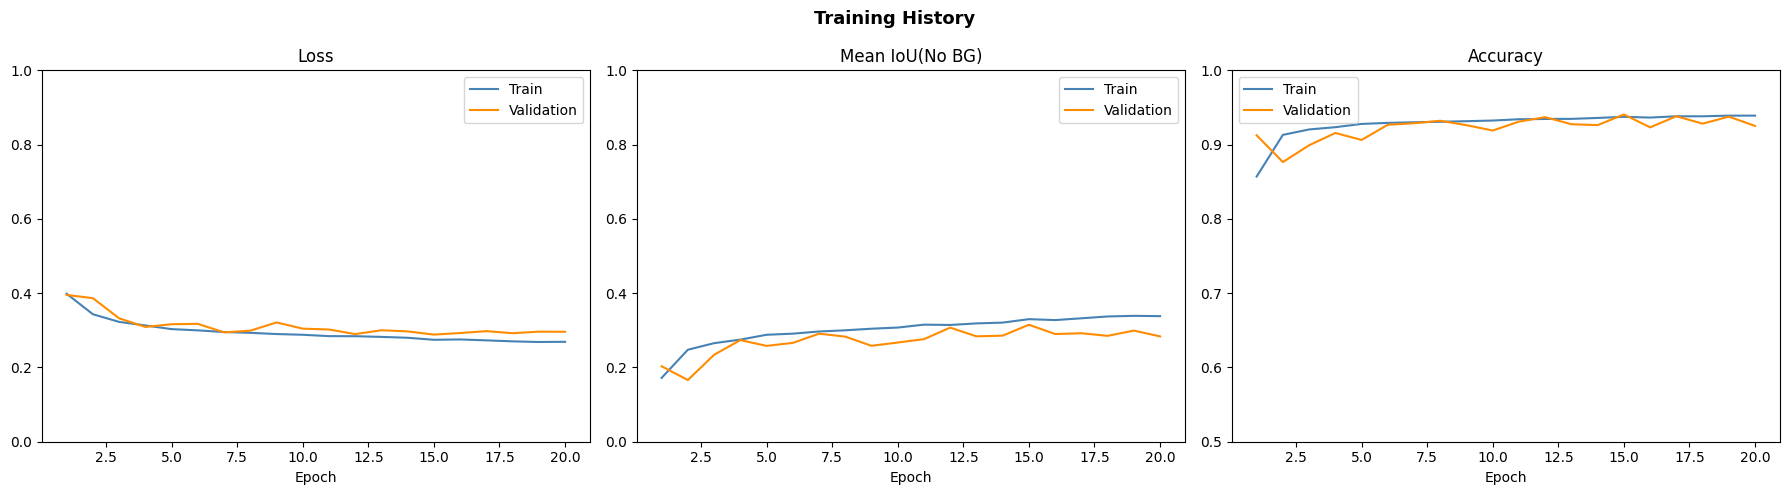

Saved : /content/model3_resnet50_u_net_v1_7/results/training_history_phase1.png


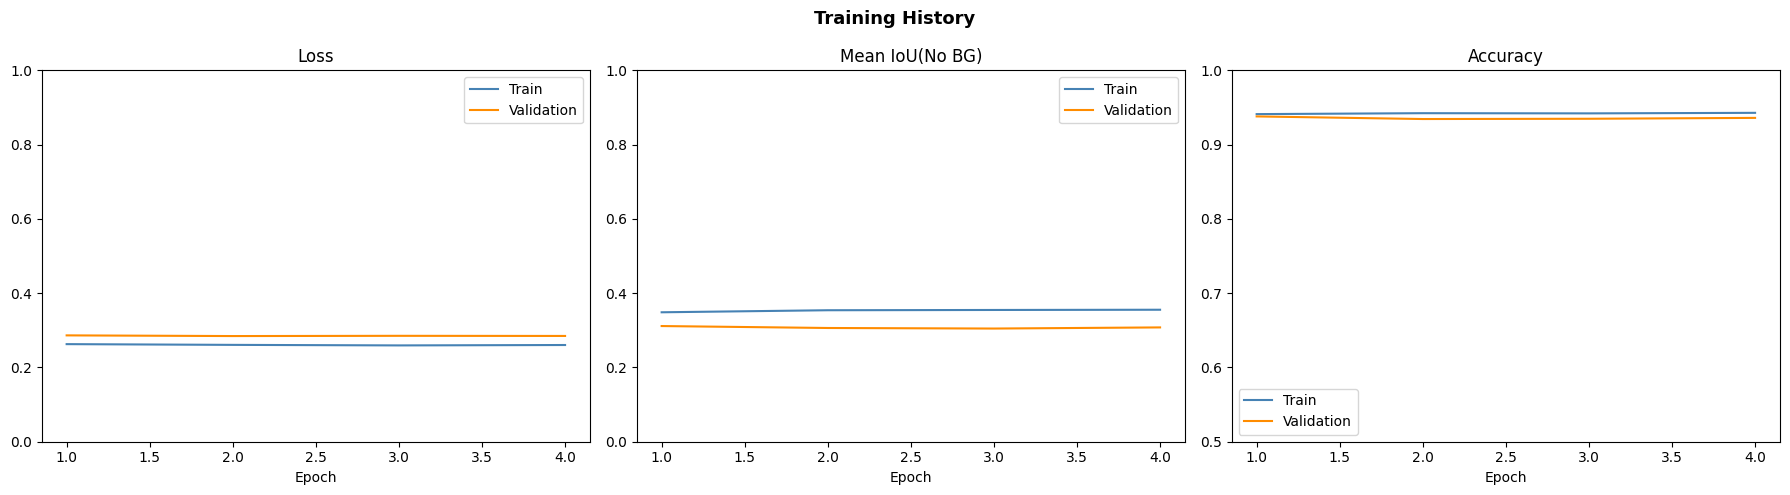

Saved : /content/model3_resnet50_u_net_v1_7/results/training_history_phase2.png


In [35]:
def plot_history(history, path, ylim_loss=(0, 1.0), ylim_iou=(0, 1.0), ylim_acc=(0.5, 1.0)):
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    iou      = history.history["mean_iou_no_bg"]
    val_iou  = history.history["val_mean_iou_no_bg"]
    acc      = history.history["categorical_accuracy"]
    val_acc  = history.history["val_categorical_accuracy"]

    epochs_total = range(1, len(loss) + 1)
    fig, axes    = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training History", fontsize=13, fontweight="bold")

    for ax, tr, va, title, ylim in zip(
        axes,
        [loss,     iou,        acc],
        [val_loss, val_iou,    val_acc],
        ["Loss",   "Mean IoU(No BG)", "Accuracy"],
        [ylim_loss, ylim_iou,  ylim_acc]
    ):
        ax.plot(epochs_total, tr, label="Train",      color="steelblue")
        ax.plot(epochs_total, va, label="Validation", color="darkorange")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylim(ylim)
        ax.legend()

    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved : {path}")


# Phase 1
path = os.path.join(RESULT_DIR, "training_history_phase1.png")
plot_history(history_phase1, path)

# Phase 2
if history_phase2 and len(history_phase2.history["loss"]) > 0:
    path = os.path.join(RESULT_DIR, "training_history_phase2.png")
    plot_history(history_phase2, path)
else:
    print("Phase 2 did not improve, skipping ft_history plot.")

In [21]:
# TEST EVALUATION
best_path = FINE_CKPT_PATH if os.path.exists(FINE_CKPT_PATH) else HEAD_CKPT_PATH
best_model = load_saved_model(best_path)

results = best_model.evaluate(test_dataset, verbose=1)
print("\nFinal test results")
print(f"  Loss                 : {results[0]:.4f}")
print(f"  Categorical accuracy : {results[1]:.4f}")
print(f"  Mean IoU no bg       : {results[2]:.4f}")


19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 800ms/step - categorical_accuracy: 0.9369 - loss: 0.2959 - mean_iou_no_bg: 0.3072

Final test results
  Loss                 : 0.2959
  Categorical accuracy : 0.9369
  Mean IoU no bg       : 0.3072


In [22]:
# PER-CLASS IoU
all_preds = []
all_masks = []

for images, masks in test_dataset:
    preds = best_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=-1)
    masks = np.argmax(masks.numpy(), axis=-1)
    all_preds.append(preds)
    all_masks.append(masks)

all_preds = np.concatenate(all_preds, axis=0)
all_masks = np.concatenate(all_masks, axis=0)

def compute_iou(preds, masks, class_id):
    pred_c = preds == class_id
    mask_c = masks == class_id
    intersection = np.logical_and(pred_c, mask_c).sum()
    union = np.logical_or(pred_c, mask_c).sum()
    if union == 0:
        return float("nan")
    return intersection / union

iou_scores = {}
print("\nPer-class IoU")
for class_id, class_name in CLASS_NAMES.items():
    iou = compute_iou(all_preds, all_masks, class_id)
    iou_scores[class_name] = iou
    print(f"  {class_name:<15}: {iou:.4f}" if not np.isnan(iou) else f"  {class_name:<15}: nan")



Per-class IoU
  background     : 0.9536
  grass_short    : 0.5249
  grass_medium   : 0.2215
  grass_long     : 0.1751


In [23]:
# Define thresholds for status
GOOD_THRESHOLD = 0.7
ACCEPTABLE_THRESHOLD = 0.4

def get_status(iou):
    if np.isnan(iou):
        return "N/A"
    elif iou >= GOOD_THRESHOLD:
        return "GOOD"
    elif iou >= ACCEPTABLE_THRESHOLD:
        return "ACCEPTABLE"
    else:
        return "POOR"

print("===== PER CLASS IoU ===\n")
print(f"{  'Class Name':<20} {'IoU':<10} {'Status'}")
print("---------------------------------------------")

for class_id, class_name in CLASS_NAMES.items():
    iou = iou_scores.get(class_name, np.nan)
    status = get_status(iou)
    iou_str = f"{iou:.4f}" if not np.isnan(iou) else "nan   "
    print(f"{class_id:<4} {class_name:<16} {iou_str:<10} {status}")

print("\n" + "  Mean IoU (mIoU) : " + f"{results[2]:.4f}")

===== PER CLASS IoU ===

Class Name           IoU        Status
---------------------------------------------
0    background       0.9536     GOOD
1    grass_short      0.5249     ACCEPTABLE
2    grass_medium     0.2215     POOR
3    grass_long       0.1751     POOR

  Mean IoU (mIoU) : 0.3072


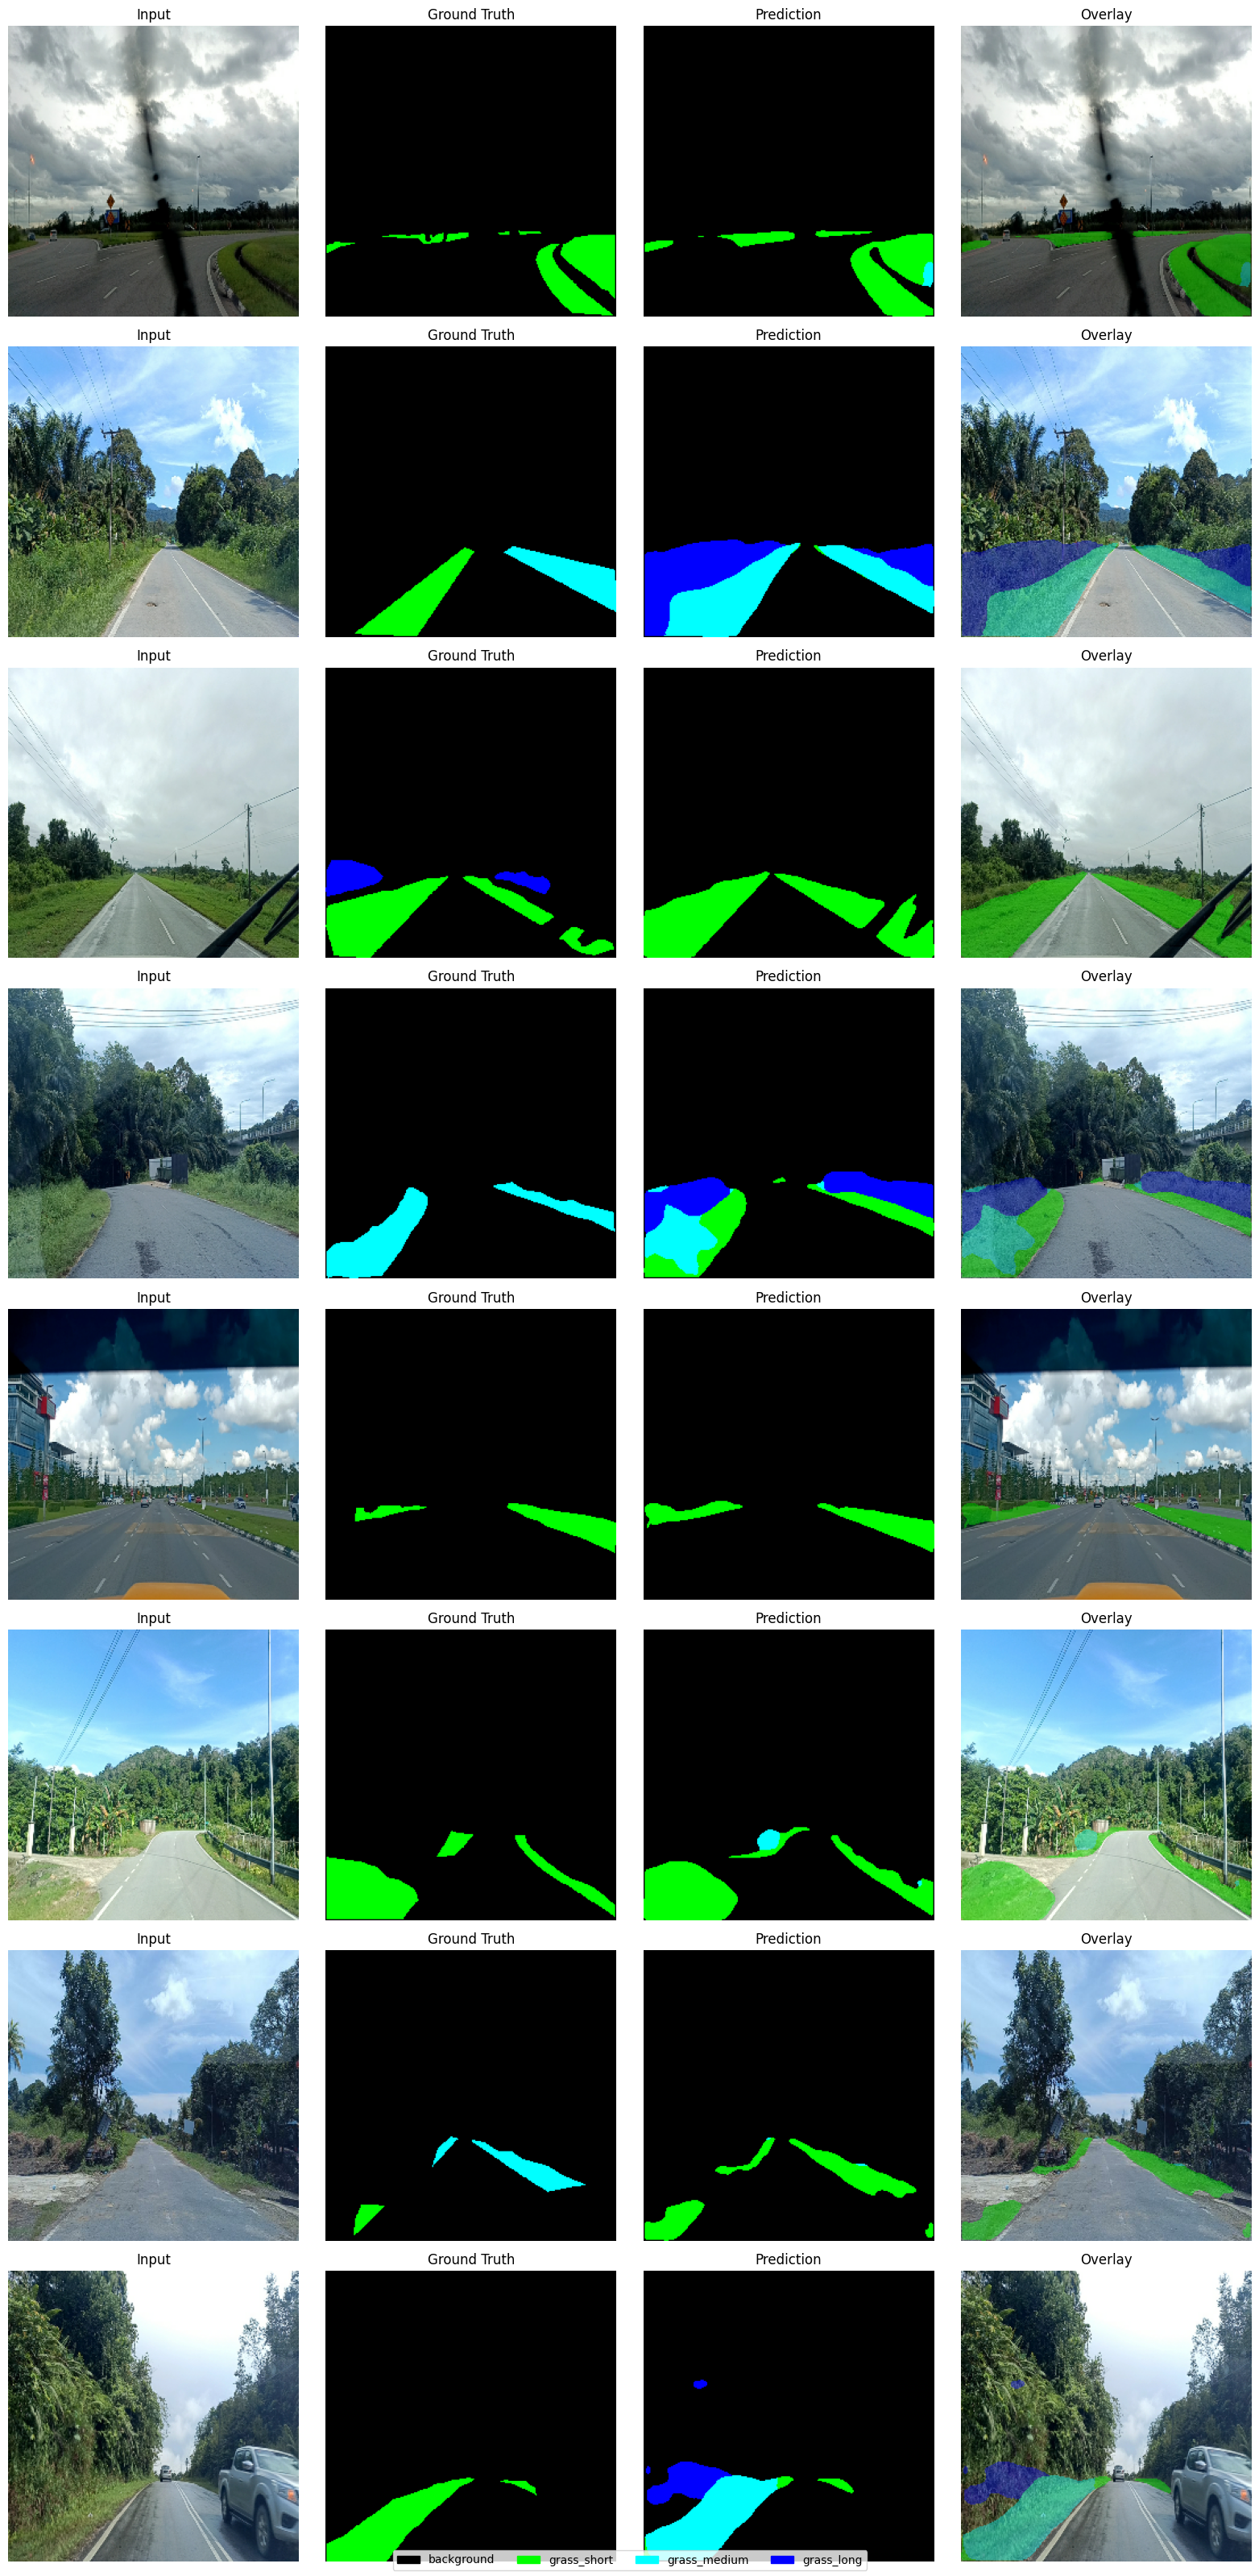

In [24]:
# PREDICTION VISUALIZATION
def show_predictions(dataset, model, n=8):
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    count = 0
    for images, masks in dataset:
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=-1)

        for i in range(len(images)):
            if count >= n:
                break

            img = deprocess_resnet_image(images[i].numpy())
            gt = np.argmax(masks[i].numpy(), axis=-1)
            pr = preds[i]

            gt_rgb = mask_to_rgb(gt)
            pr_rgb = mask_to_rgb(pr)

            overlay = img.copy()
            alpha = 0.4
            for cid, color in CLASS_COLORS.items():
                if cid == 0:
                    continue
                region = pr == cid
                overlay[region] = (
                    overlay[region] * (1 - alpha) + np.array(color) * alpha
                ).astype(np.uint8)

            axes[count, 0].imshow(img)
            axes[count, 0].set_title("Input")
            axes[count, 0].axis("off")

            axes[count, 1].imshow(gt_rgb)
            axes[count, 1].set_title("Ground Truth")
            axes[count, 1].axis("off")

            axes[count, 2].imshow(pr_rgb)
            axes[count, 2].set_title("Prediction")
            axes[count, 2].axis("off")

            axes[count, 3].imshow(overlay)
            axes[count, 3].set_title("Overlay")
            axes[count, 3].axis("off")

            count += 1

        if count >= n:
            break

    patches = [
        mpatches.Patch(color=np.array(color) / 255.0, label=CLASS_NAMES[cid])
        for cid, color in CLASS_COLORS.items()
    ]
    fig.legend(handles=patches, loc="lower center", ncol=4)
    plt.tight_layout()
    save_path = os.path.join(RESULT_DIR, "test_predictions.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

show_predictions(test_dataset, best_model, n=8)


In [25]:
import datetime

#SAVE REPORT
report = {
    "generated_at": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model": "ResNet50 + U-Net",
    "parameter_alignment": {
        "image_size": list(IMG_SHAPE),
        "batch_size": BATCH_SIZE,
        "training_epochs": {"phase1": PHASE1_EPOCHS, "phase2": PHASE2_EPOCHS},
        "class_weights": CLASS_WEIGHTS,
        "random_seed": SEED,
        "augmentation": ["vertical_flip", "horizontal_flip", "contrast", "saturation", "hue"],
        "decoder_filter_size": DECODER_FILTERS,
        "dropout": DROPOUT_RATE,
        "loss_function": "Weighted CCE + Focal Loss + Tversky Loss",
        "optimizer": "Adam",
        "learning_rate": {"phase1": PHASE1_LR, "phase2": PHASE2_LR},
        "early_stopping": {"monitor": "mean_iou_no_bg", "phase1_patience": 12, "phase2_patience": 3},
        "reduce_lr_on_plateau": {"min_lr": 1e-6, "phase1_patience": 5, "phase2_patience": 2},
        "metrics": ["categorical_accuracy", "mean_iou_no_bg"],
        "phase1_training": "Freeze pre-trained ResNet50 encoder",
        "phase2_training": "Unfreeze last 25% of pre-trained model, keep BatchNorm frozen"
    },
    "dataset": {
        "train": len(train_img_paths),
        "val": len(val_img_paths),
        "test": len(test_img_paths)
    },
    "test_results": {
        "loss": float(results[0]),
        "categorical_accuracy": float(results[1]),
        "mean_iou_no_bg": float(results[2])
    },
    "per_class_iou": {
        k: (None if np.isnan(v) else float(v)) for k, v in iou_scores.items()
    }
}

with open(REPORT_PATH, "w") as f:
    json.dump(report, f, indent=2)

print(f"\nSaved report to: {REPORT_PATH}")


Saved report to: /content/model3_resnet50_u_net_v1_7/results/evaluation_report.json


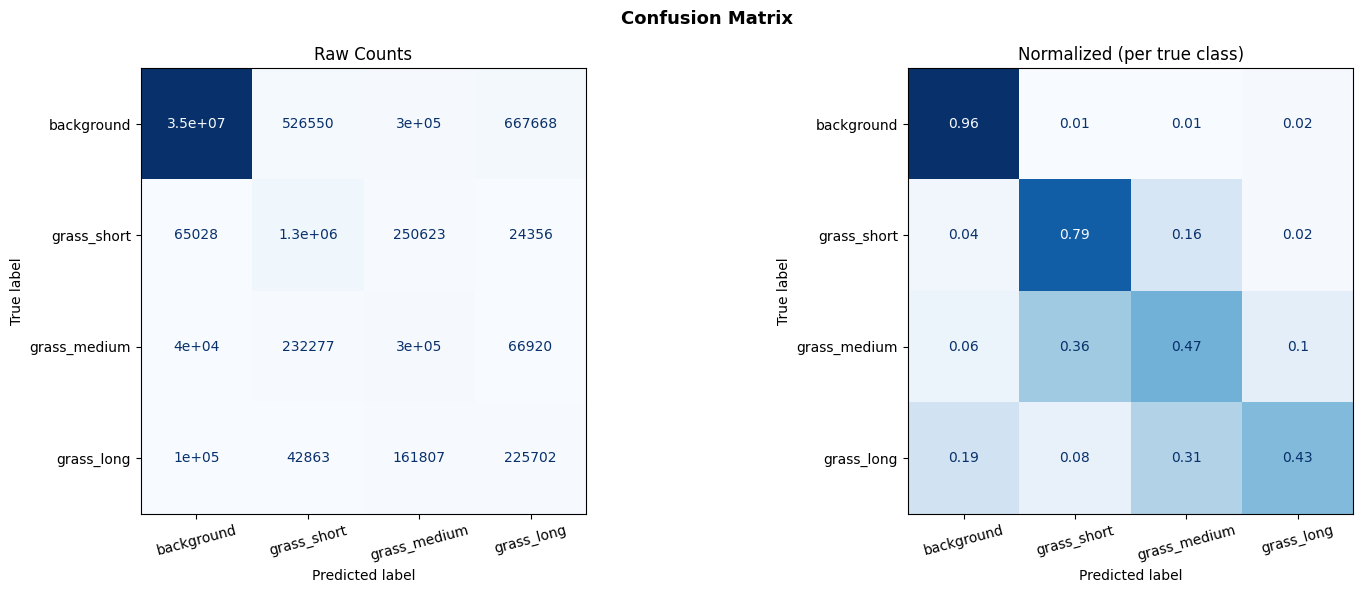

Saved : /content/model3_resnet50_u_net_v1_7/results/confusion_matrix.png


In [26]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Flatten all predictions and masks
y_true_flat = all_masks.flatten()
y_pred_flat = all_preds.flatten()

# Compute confusion matrix
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=[0, 1, 2, 3])

# Normalized version (shows % instead of raw counts)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

# Plot both side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix", fontsize=13, fontweight="bold")

class_labels = list(CLASS_NAMES.values())

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Raw Counts")
axes[0].set_xticklabels(class_labels, rotation=15)

# Normalized
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2), display_labels=class_labels)
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Normalized (per true class)")
axes[1].set_xticklabels(class_labels, rotation=15)

plt.tight_layout()
path = os.path.join(RESULT_DIR, "confusion_matrix.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved : {path}")

In [27]:
import shutil
from google.colab import files

# Define the directory to zip (the model's output directory)
dir_to_zip = OUTPUT_ROOT
archive_name = os.path.join("/content", os.path.basename(dir_to_zip))

# Zip the folder
shutil.make_archive(archive_name, 'zip', dir_to_zip)

# Download
files.download(archive_name + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
# Save all 600 predictions individually

OUTPUT_DIR = os.path.join(RESULT_DIR, "individual_predictions")
os.makedirs(OUTPUT_DIR, exist_ok=True)

count = 0

# Iterate through the test_dataset
for images, masks_one_hot in test_dataset:
    preds = best_model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=-1)

    for i in range(len(images)):
        img = deprocess_resnet_image(images[i].numpy())
        gt_mask   = tf.argmax(masks_one_hot[i], axis=-1).numpy().astype(np.int32) # Convert one-hot to class indices
        pred_mask = preds[i]

        # Ground truth RGB
        gt_rgb = np.zeros((*gt_mask.shape, 3), dtype=np.uint8)
        for cid, color in CLASS_COLORS.items():
            gt_rgb[gt_mask == cid] = color

        # Prediction RGB
        pred_rgb = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)
        for cid, color in CLASS_COLORS.items():
            pred_rgb[pred_mask == cid] = color

        # Overlay
        overlay = img.copy()
        alpha   = 0.4
        for cid, color in CLASS_COLORS.items():
            if cid == 0:
                continue
            region          = pred_mask == cid
            overlay[region] = (
                overlay[region] * (1 - alpha) +
                np.array(color) * alpha
            ).astype(np.uint8)

        # Classes present — shown in title
        gt_classes   = [CLASS_NAMES[c] for c in np.unique(gt_mask)]
        pred_classes = [CLASS_NAMES[c] for c in np.unique(pred_mask)]

        # 4-panel figure
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(
            f"Image {count+1:04d}  |  GT: {gt_classes}  |  Pred: {pred_classes}",
            fontsize=10
        )
        axes[0].imshow(img);      axes[0].set_title("Input");        axes[0].axis("off")
        axes[1].imshow(gt_rgb);   axes[1].set_title("Ground Truth"); axes[1].axis("off")
        axes[2].imshow(pred_rgb); axes[2].set_title("Prediction");   axes[2].axis("off")
        axes[3].imshow(overlay);  axes[3].set_title("Overlay");      axes[3].axis("off")

        patches = [mpatches.Patch(color=np.array(c)/255, label=CLASS_NAMES[k])
                   for k, c in CLASS_COLORS.items()]
        fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=9)

        plt.tight_layout()
        plt.savefig(
            os.path.join(OUTPUT_DIR, f"{count+1:04d}_compare.png"),
            dpi=100,
            bbox_inches="tight"
        )
        plt.close()  # critical — prevents memory crash

        count += 1
        if count % 50 == 0:
            print(f"  Saved {count}/{len(test_img_paths)}...")

print(f"\nDone! All {count} images saved to:\n  {OUTPUT_DIR}")

import shutil
from google.colab import files

# Define the directory to zip (the individual predictions directory)
dir_to_zip = OUTPUT_DIR
archive_name = os.path.join("/content", os.path.basename(dir_to_zip))

# Zip the folder
shutil.make_archive(archive_name, 'zip', dir_to_zip)

# Download
files.download(archive_name + ".zip")

  Saved 50/600...
  Saved 100/600...
  Saved 150/600...
  Saved 200/600...
  Saved 250/600...
  Saved 300/600...
  Saved 350/600...
  Saved 400/600...
  Saved 450/600...
  Saved 500/600...
  Saved 550/600...
  Saved 600/600...

Done! All 600 images saved to:
  /content/model3_resnet50_u_net_v1_7/results/individual_predictions


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>